In [311]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [312]:
df = pd.read_csv('fraude_bancaire_synthetique_final.csv')

In [327]:
df.head()

,age,salaire,score_credit,montant_transaction,anciennete_compte,type_carte,region,genre,fraude
0,49.548894,183659.045784,48.228579,9.649456e+06,14.0,Mastercard,Houston,femelle,0
1,44.952665,329732.599158,67.573097,2.500000e+04,10.0,Mastercard,Houston,femelle,0
2,41.659910,75000.000000,77.559487,2.724004e+06,9.0,Visa,Houston,male,0
3,42.377280,75000.000000,54.282220,4.755632e+06,9.0,Mastercard,Orlando,femelle,0
4,48.125023,359999.482942,71.148546,2.500000e+04,8.0,Mastercard,Orlando,femelle,0


In [328]:
print(df.isnull().sum())
print(df['fraude'].value_counts())

age                    0
salaire                0
score_credit           0
montant_transaction    0
anciennete_compte      0
type_carte             0
region                 0
genre                  0
fraude                 0
dtype: int64
fraude
0    911
1     45
Name: count, dtype: int64


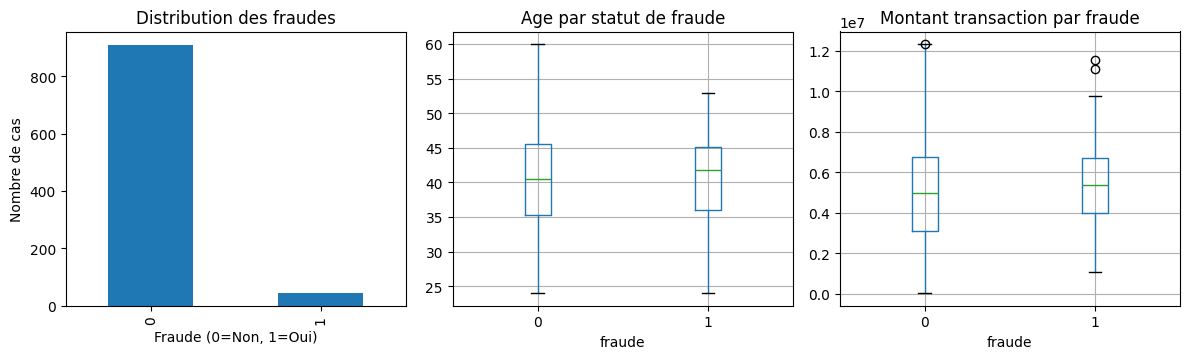

Pourcentage de fraudes: 4.71 %


In [329]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['fraude'].value_counts().plot(kind='bar')
plt.title('Distribution des fraudes')
plt.xlabel('Fraude (0=Non, 1=Oui)')
plt.ylabel('Nombre de cas')


plt.subplot(1, 3, 2)
df.boxplot(column='age', by='fraude', ax=plt.gca())
plt.title('Age par statut de fraude')
plt.suptitle('')


plt.subplot(1, 3, 3)
df.boxplot(column='montant_transaction', by='fraude', ax=plt.gca())
plt.title('Montant transaction par fraude')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Pourcentage de fraudes:", round(df['fraude'].mean() * 100, 2), "%")

In [313]:
# nettoyage generale du datasert

df = df.dropna(subset=['fraude'])
df['fraude'] = df['fraude'].astype(int)

num_features = ['age', 'salaire', 'score_credit', 'montant_transaction', 'anciennete_compte']
cat_features = ['type_carte', 'region', 'genre']



df[num_features] = df[num_features].fillna(df[num_features].median())

df[cat_features] = df[cat_features].fillna('inconnu')

In [314]:
# Calcul IQR par variable
Q1 = df[num_features].quantile(0.25)
Q3 = df[num_features].quantile(0.75)
IQR = Q3 - Q1

# Filtrage des données dans les bornes
condition = ~(((df[num_features] < (Q1 - 1.5 * IQR)) | (df[num_features] > (Q3 + 1.5 * IQR))).any(axis=1))

print(f"notre dataset a des outlier detectés : {(~condition).sum()}")

notre dataset a des outlier detectés : 17


In [315]:
# Je les suprimmes
df = df[condition]

In [316]:
df = df.drop_duplicates()

In [317]:
X = df.drop('fraude', axis=1)
y = df['fraude']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

X_trasformed = preprocessor.fit_transform(X)

In [318]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_trasformed, y)

In [319]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.2, random_state=42)

In [320]:
model = RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42
        )

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [321]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("les resultats des metiques")
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(f"roc auc: {roc_auc_score(y_test, y_proba):.4f}")


les resultats des metiques
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       212
           1       0.98      0.96      0.97       225

    accuracy                           0.97       437
   macro avg       0.97      0.97      0.97       437
weighted avg       0.97      0.97      0.97       437

[[207   5]
 [  9 216]]
roc auc: 0.9927


In [322]:
import pickle


with open('preprocessor.pkl', 'wb') as file:
    pickle.dump(preprocessor, file)


with open('fraud_detection_model.pkl', 'wb') as file:
    pickle.dump(model, file)

feature_names = {
    'num_features': num_features,
    'cat_features': cat_features
}

with open('feature_names.pkl', 'wb') as file:
    pickle.dump(feature_names, file)